# Energy Predeiction From Power Plant Dataset=

# 1. Importing Required Libaries 

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn


# 2. Importing dataset and bit Visualisation 

In [154]:
df = pd.read_csv("dataset/energy_powerplant_data.csv")

In [155]:
df.head() 

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


# 3. Train Test Split

In [157]:
from sklearn.model_selection import train_test_split

X = df.drop("PE", axis=1)
Y = df["PE"]

In [158]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Scalling 

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [160]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

# 5. Using Pytorch for ANN

In [161]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

# 6. DataSet and DataLoader

In [162]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 7. ANN Model (Deep Learning)

In [163]:

# Define our ANN model
class EnergyPredictor(nn.Module):
    def __init__(self, input_size):
        super(EnergyPredictor, self).__init__()

        self.model = nn.Sequential(

            # first hidden layer
            nn.Linear(input_size, 6),
            nn.ReLU(),

            # second hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)
    

In [164]:
import torch.optim as optim

model = EnergyPredictor(X_train.shape[1]) # input size is number of features

criterion = nn.MSELoss() # loss function for regression
optimizer = optim.Adam(model.parameters()) # optimizer to update model parameters

# 8. Traning ANN model

In [165]:
training_losses = []  
val_losses = []

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for Xb, Yb in train_loader:

        optimizer.zero_grad() # clear previous gradients

        predictions = model(Xb) # predict output for current batch
        loss = criterion(predictions, Yb) # compute loss
        loss.backward() # backpropagation to compute gradients
        optimizer.step() # update model parameters

        running_loss += loss.item() # loss is a tensor, we need to get its value using .item()

    epoch_loss = running_loss / len(train_loader) # average loss for the epoch
    training_losses.append(epoch_loss) # store the loss for plotting later

    # validation step (optional, can be done every few epochs)

    running_val_loss = 0.0
    model.eval() # set model to evaluation mode

    with torch.no_grad(): # disable gradient computation for validation
        for Xb, Yb in test_loader:
            val_predictions = model(Xb)
            val_loss = criterion(val_predictions, Yb)
            running_val_loss += val_loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss) # store validation loss for plotting
  

# 9. Visuslation of the ANN loss 

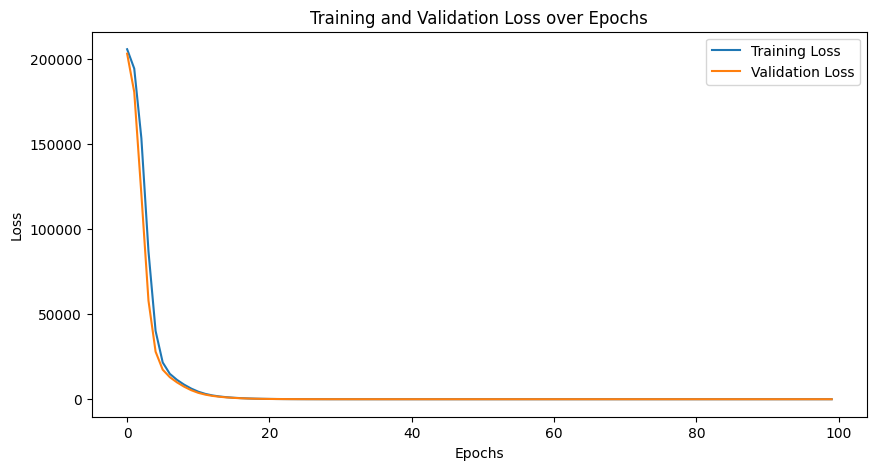

In [166]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(training_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()  